In [2]:
using Revise
includet("world.jl")
includet("ParetoRRTStar.jl")
includet("ParetoPlanner.jl")

In [39]:
using Random
Random.seed!(1337)
using StaticArrays
using .World
domain = (@SVector[0.0, 0.0, 0.0], @SVector[120, 100, 2*pi])
goal = @SVector [90.0, 90.0, 0.0] # x, y, yaw
start = @SVector [10.0, 10.0, 0.0] # x, y, yaw

# can add unsafe zones here
zone1 = World.Circle(@SVector[45.0, 45.0],10.0)
# zone4 = World.Circle(@SVector[100.0, 100.0],50.0)
# zone5 = World.Circle(@SVector[40.0, 110.0],20.0)
# zone2 = World.Rectangle(@SVector[95.0, 135.0], 80.0, 30.0, -2pi/5)
# zone3 = World.Rectangle(@SVector[80.0, 30.0], 40.0, 10.0, pi/4)
unsafe_zones = World.AbstractUnsafeZone[zone1]
risk_zone = @SVector[70.0, 50.0, 30.0] # x, y, radius

P = ParetoPlannerProblem(domain = domain, unsafe_zones = unsafe_zones, risk_zone = risk_zone)
nodes = [ ParetoRRTStar.Node(start, ParetoRRTStar.ParetoPath{2,Float64}[])]

max_iter = 1000
@time ParetoRRTStar.rrt_star!(P, nodes, max_iter)



iter: 10, new node: 11, pareto parents: 1
iter: 30, new node: 25, pareto parents: 1
iter: 50, new node: 37, pareto parents: 4
iter: 60, new node: 45, pareto parents: 8
iter: 70, new node: 55, pareto parents: 1
iter: 80, new node: 65, pareto parents: 3
iter: 90, new node: 74, pareto parents: 7
iter: 100, new node: 84, pareto parents: 6
iter: 110, new node: 94, pareto parents: 1
iter: 120, new node: 104, pareto parents: 1
iter: 130, new node: 113, pareto parents: 1
iter: 140, new node: 122, pareto parents: 10
iter: 150, new node: 131, pareto parents: 11
iter: 160, new node: 141, pareto parents: 1
iter: 170, new node: 150, pareto parents: 1
iter: 180, new node: 160, pareto parents: 11
iter: 190, new node: 170, pareto parents: 1
iter: 200, new node: 179, pareto parents: 8
iter: 210, new node: 189, pareto parents: 3
iter: 220, new node: 199, pareto parents: 1
iter: 230, new node: 209, pareto parents: 1
iter: 240, new node: 219, pareto parents: 20
iter: 250, new node: 229, pareto parents: 22

Number of Pareto front paths: 20


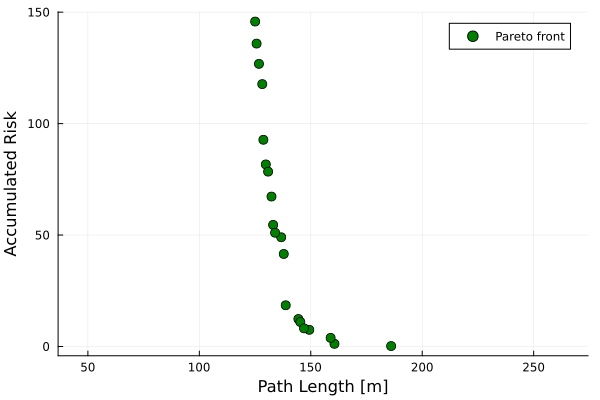

In [40]:
using LinearAlgebra
using Plots
goal_found = false
min_dist = Inf
min_node = 0
for i in 1:length(nodes)
    n = nodes[i]
    if norm(n.state[1:2] - goal[1:2]) < min_dist
        min_dist = norm(n.state[1:2] - goal[1:2])
        min_node = i
    end
end

m = nodes[min_node]
pareto_front = m.pareto_paths
print("Number of Pareto front paths: ", length(pareto_front), "\n")

pf_x = [pf.cost[1] for pf in pareto_front]
pf_y = [pf.cost[2] for pf in pareto_front]
scatter(pf_x, pf_y, label = "Pareto front", color = :green, markersize = 5)
plot!(xlabel = "Path Length [m]", ylabel = "Accumulated Risk", aspect_ratio = :equal)



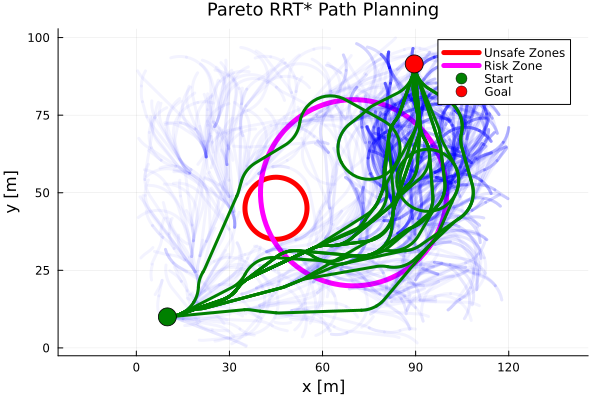

In [41]:
includet("plotting.jl")
using Plots

plot()
plot!(unsafe_zones; color = :red, linewidth=5, label = "Unsafe Zones")
plot!([World.Circle(risk_zone[SOneTo(2)], risk_zone[3])]; color = :magenta, linewidth=5, label = "Risk Zone")
plot!(nodes, P.turning_radius;linewidth = 3,color=:blue, label=false, opacity=0.05)
plot_pareto_front(nodes, min_node, P.turning_radius; color = :green, label = false, linewidth = 3)
scatter!([start[1]], [start[2]], label = "Start", color = :green, markersize = 10)
scatter!([nodes[min_node].state[1]], [nodes[min_node].state[2]], label = "Goal", color = :red, markersize = 10, aspect_ratio = :equal)
plot!(legend = :topright, title = "Pareto RRT* Path Planning", titlefont = font(12), xlabel = "x [m]", ylabel = "y [m]")